In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from itertools import product
from tqdm import tqdm

In [231]:
def BBM4(N = 10, Re = 10):
    U = 1
    
    h = 1. / ( N - 1 )
    ht = 1. / 1000
    res = 1. / 100
    err = np.inf
    
    mesh_w = np.empty( ( 2, N, N ) )
    mesh_psi = np.empty( ( 2, N, N ) )
    
    mesh_w[0, :, :] = 0
    mesh_w[0, :, -1] = -2 * U / h
    mesh_psi[0, :, :] = 0

    while (err > res):
        for i in tqdm(range(N)):
            for j in range(N):
                if ( ( i == 0 ) | ( i == N - 1 ) ) & ( j == 0 ):
                    mesh_w[1, i, j] = 0
                elif ( i == 0 ) & ( j == N - 1 ):
                    mesh_w[1, i, j] = mesh_w[0, i + 1, j]
                elif ( i == N - 1 ) & ( j == N - 1 ):
                    mesh_w[1, i, j] = mesh_w[0, i - 1, j]
                elif ( j == 0 ):
                    mesh_w[1, i, j] = 2 * (mesh_psi[0, i, j] - mesh_psi[0, i, j+1])/( h**2 )
                elif ( j == N - 1 ):
                    mesh_w[1, i, j] = 2 * (mesh_psi[0, i, j] - mesh_psi[0, i, j-1])/( h**2 ) - 2 * U / h
                elif ( i == 0 ):
                    mesh_w[1, i, j] = 2 * (mesh_psi[0, i, j] - mesh_psi[0, i+1, j])/( h**2 )
                elif ( i == N - 1 ):
                    mesh_w[1, i, j] = 2 * (mesh_psi[0, i, j] - mesh_psi[0, i-1, j])/( h**2 )
                else:
                    mesh_w[1, i, j] = mesh_w[0, i, j] + ( ht / ( h ** 2 ) ) * ( -( mesh_psi[0, i, j + 1] - mesh_psi[0, i, j - 1] ) * 
                                                                  ( mesh_w[0, i + 1, j] - mesh_w[0, i - 1, j] ) / 4 +
                                                                  ( mesh_w[0, i, j + 1] - mesh_w[0, i, j - 1] ) *
                                                                  ( mesh_psi[0, i + 1, j] - mesh_psi[0, i - 1, j] ) / 4 +
                                                                  ( 1. / Re ) * ( mesh_w[0, i, j + 1] + mesh_w[0, i, j - 1] + 
                                                                                 mesh_w[0, i + 1, j] + mesh_w[0, i - 1, j] - 
                                                                                 4 * mesh_w[0, i, j] )
                                                                 )
        for i in range(N):
            for j in range(N):
                if ( j == 0 ):
                    mesh_psi[1, i, j] = 0
                elif ( i == N - 1 ):
                    mesh_psi[1, i, j] = 0
                elif ( i == 0 ):
                    mesh_psi[1, i, j] = 0
                elif ( j == N - 1 ):
                    mesh_psi[1, i, j] = 0
                else:
                    mesh_psi[1, i, j] = ( 1. / 4 ) * ( mesh_psi[0, i, j + 1] + mesh_psi[0, i, j - 1] + 
                                                           mesh_psi[0, i + 1, j] + mesh_psi[0, i - 1, j] + ( h ** 2 ) * mesh_w[0, i, j]
                                                         )
        
        err = np.max( np.abs( mesh_w[0, :, :] - mesh_w[1, :, :] ) / ht )
        print(err)
        mesh_psi[0, :, :] = np.copy( mesh_psi[1, :, :] )
        mesh_w[0, :, :] = np.copy( mesh_w[1, :, :] )
        mesh_psi[1, :, :] = 0
        mesh_w[1, :, :] = 0

    return mesh_w[0, :, :], mesh_psi[0, :, :]

In [232]:
N = 40
h = 1. / ( N - 1 )
w, psi = BBM4(N = N, Re = 10)

100%|████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 3467.08it/s]


11863.800000000001
8254.83204
6018.174146790002
7093.366020000005
7152.074330894998
6464.98711333124
5533.091134176196
4576.197286339258


100%|████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 2940.64it/s]

3709.5716061788266
2976.8767134723576
2384.357892042459
1919.4448174644947
1562.0755213889338
1290.8906220604379
1086.3409891437002
931.9555740200371
814.5889033722113



  0%|                                                                                           | 0/40 [00:00<?, ?it/s]

...

0.01074005732482064
0.010693630394520426
0.010651773539205323
0.010605462165136359
0.010563694831766668
0.01051750157410325
0.010475826463185456



100%|████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 2665.38it/s]


0.010429753840135447
0.010388173609099383
0.010342224092907415
0.010300741354329901
0.010254917373497818
0.010213534697323112
0.010167838639052462
0.010126558549261588
0.010080992756567042


100%|████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 3986.70it/s]

0.010039817735840728
0.009994384511102794


In [233]:
u = np.empty( ( N, N ) )
v = np.empty( ( N, N ) )
for i in range(N):
    for j in range(N):
        if ( j == 0 ):
            u[i, j] = 0
            v[i, j] = 0
        elif ( i == N - 1 ):
            u[i, j] = 0
            v[i, j] = 0
        elif ( i == 0 ):
            u[i, j] = 0
            v[i, j] = 0
        elif ( j == N - 1 ):
            u[i, j] = 1
            v[i, j] = 0
        else:
            u[i, j] = ( psi[i, j + 1] - psi[i, j - 1] ) / ( 2 * h )
            v[i, j] = ( psi[i + 1, j] - psi[i - 1, j] ) / ( 2 * h )

In [234]:
x = y = np.linspace(0, 1, N)
xi, yi = np.meshgrid(x, y)

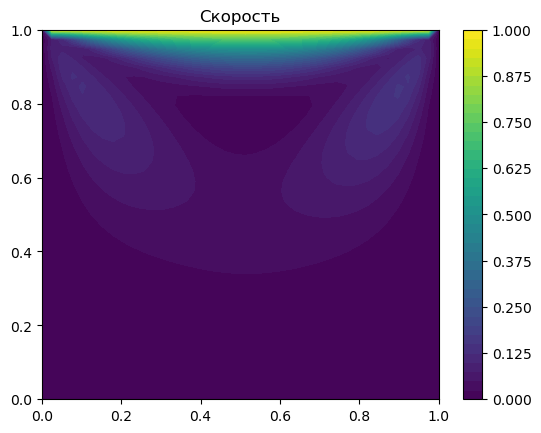

In [235]:
plt.contourf(yi, xi, (u**2 + v**2), 40)
plt.title("Скорость")
plt.colorbar()
plt.show()

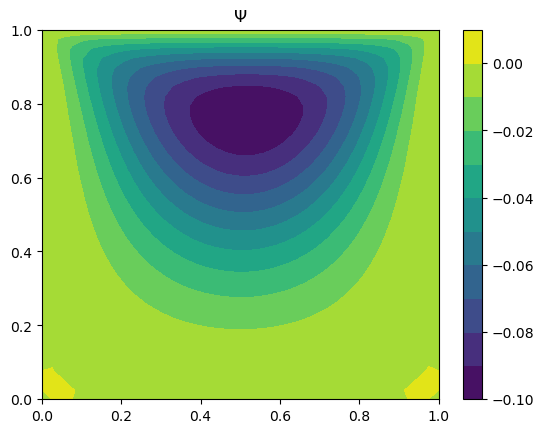

In [236]:
plt.contourf(yi, xi, psi, 10)
plt.title("Ψ")
plt.colorbar()
plt.show()

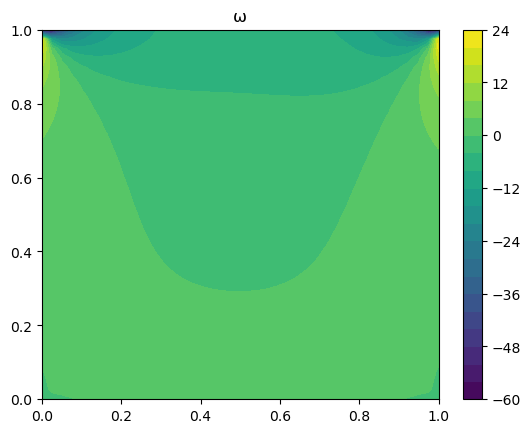

In [237]:
plt.contourf(yi, xi, w, 20)
plt.title("ω")
plt.colorbar()
plt.show()